In [ ]:
# Boat Price prediction

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    make_scorer,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

1. Load and Understand the data

In [62]:
# Input the path to the dataset
dataset_path =  r"C:\Users\a2839\PycharmProjects\SqptInterview\BoatPrice\Boats_Cleaned_dataset.csv"

df = pd.read_csv(dataset_path)
df.head(20)

,Unnamed: 0,id,type,boatClass,make,model,year,condition,length_ft,beam_ft,dryWeight_lb,hullMaterial,fuelType,numEngines,totalHP,maxEngineYear,minEngineYear,engineCategory,price,sellerId,city,state,zip,created_date,created_month,created_year
0,1,7252689,power,power-center,Aquasport,210 CC,1992,used,21.0000,8.5000,"3,000.0000",fiberglass,gasoline,1,150.0000,NaN,NaN,outboard-4s,"16,500.0000",217053,Englewood,FL,34224,2019-10-16,10,2019
1,3,7228300,power,power-sportcruiser,Formula,400 Super Sport,2018,used,40.0000,11.0000,"16,100.0000",fiberglass,diesel,2,800.0000,"2,018.0000","2,018.0000",inboard-outboard,"539,000.0000",44260,Harsens Island,MI,48028,2019-09-24,9,2019
2,5,7271336,power,power-deck,Bayliner,Element 180,2020,new,18.0000,7.4200,"2,000.0000",fiberglass,gasoline,1,75.0000,"2,019.0000","2,019.0000",outboard-4s,"26,995.0000",220570,Marietta,OH,45750,2019-11-02,11,2019
3,6,7222952,power,power-expresscruiser,Regal,32 Express,2015,used,32.0000,10.3300,"12,650.0000",fiberglass,gasoline,2,600.0000,NaN,NaN,multiple,"169,995.0000",34834,North Charleston,SC,29405,2019-09-19,9,2019
4,8,6824832,power,power-aft,Carver,440 Aft Cabin Motor Yacht,1994,used,44.0000,15.0000,"32,000.0000",fiberglass,diesel,2,700.0000,"1,994.0000","1,994.0000",inboard,"109,900.0000",17942,Middle River,MD,21220,2018-08-29,8,2018
5,9,7240180,power,power-cruiser,Azimut,43,2019,used,43.0000,13.9200,"29,650.0000",fiberglass,diesel,2,800.0000,NaN,NaN,multiple,"625,000.0000",28771,Miami,FL,33140,2019-10-04,10,2019
6,10,6851456,power,power-mega,Galeon,470 SKY,2019,new,46.0000,14.3300,"36,817.0000",fiberglass,diesel,2,"1,100.0000",NaN,NaN,inboard,"949,000.0000",44179,Port Clinton,OH,43452,2018-09-21,9,2018
7,11,6851563,power,power-mega,Galeon,500 Fly,2019,new,50.0000,19.6700,"50,155.0000",fiberglass,diesel,2,"1,340.0000",NaN,NaN,inboard,"1,349,000.0000",44179,Port Clinton,OH,43452,2018-09-21,9,2018
8,13,6952573,power,power-flybridge,Johnson,Raised Pilot House,2009,used,103.0000,23.4200,"178,000.0000",fiberglass,diesel,2,"3,650.0000",NaN,NaN,inboard,"3,299,000.0000",28771,Miami,FL,33131,2019-01-09,1,2019
9,14,6920067,power,power-convertible,Hatteras,Convertible,1971,used,42.0000,13.8300,"35,400.0000",fiberglass,diesel,2,840.0000,"1,977.0000","1,977.0000",inboard,"59,500.0000",16876,Mystic,CT,06355,2018-11-26,11,2018


1.1 Tidy up the data: fake numericals? Time?

In [28]:
# Inspect the columns: are there any numerical columns that are not real numerical? (e.g. 19th district...)

# Columns that are stored as numbers but should be treated as categorical
COLUMNS_TO_STRING = [
    "zip",
    "sellerId",
]

def convert_columns_to_string(frame, columns):
    """
    Convert selected columns to string dtype if they exist in the DataFrame.
    """
    frame = frame.copy()

    for column in columns:
        if column in frame.columns:
            frame[column] = frame[column].astype(str)

    return frame


# Apply consistently to train and Kaggle test sets
df = convert_columns_to_string(df, COLUMNS_TO_STRING)
# test = convert_columns_to_string(test, COLUMNS_TO_STRING)

In [63]:
# ------------------------------------------------------------
# Combine creation date into one numerical time feature
# ------------------------------------------------------------

# Ensure created_date is datetime
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

# Use a fixed reference date
REFERENCE_DATE = pd.Timestamp("2010-01-01")

# Convert date into number of days since the reference date
df["created_days_since_ref"] = (
    df["created_date"] - REFERENCE_DATE
).dt.days

# Drop redundant date columns
df = df.drop(
    columns=[
        "created_date",
        "created_month",
        "created_year",
    ],
    errors="ignore"
)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18903 entries, 0 to 18902
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              18903 non-null  int64  
 1   id                      18903 non-null  int64  
 2   type                    18903 non-null  str    
 3   boatClass               18903 non-null  str    
 4   make                    18903 non-null  str    
 5   model                   18868 non-null  str    
 6   year                    18903 non-null  int64  
 7   condition               18903 non-null  str    
 8   length_ft               18903 non-null  float64
 9   beam_ft                 12399 non-null  float64
 10  dryWeight_lb            7094 non-null   float64
 11  hullMaterial            18903 non-null  str    
 12  fuelType                15951 non-null  str    
 13  numEngines              18903 non-null  int64  
 14  totalHP                 18055 non-null  float64
 

In [31]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,"18,903.0000",NaN,NaN,NaN,"9,782.0422","5,749.1714",1.0000,"4,783.5000","9,603.0000","14,718.5000","20,000.0000"
id,"18,903.0000",NaN,NaN,NaN,"6,947,263.3056","482,051.9241","444,913.0000","6,895,201.0000","7,061,616.0000","7,179,151.5000","7,271,336.0000"
type,18903,3,power,18610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
boatClass,18903,72,power-pontoon,4038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
make,18903,960,Tracker,1894,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,18868,7899,Z18,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,"18,903.0000",NaN,NaN,NaN,"2,013.1460",10.5030,"1,910.0000","2,011.0000","2,019.0000","2,019.0000","2,020.0000"
condition,18903,2,new,11189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length_ft,"18,903.0000",NaN,NaN,NaN,23.8039,14.6133,1.0000,18.0000,21.0000,25.0000,375.0000
beam_ft,"12,399.0000",NaN,NaN,NaN,16.1969,36.8336,0.0800,7.8300,8.5000,9.0000,"1,311.0000"


2. Data-quality Checks

2.1: Drop Problematic columns

In [64]:
# data quality check: any obvious mistakes?

quality_checks = pd.Series({
    "duplicate_rows": df.duplicated().sum(),
    "duplicate_ids": df["id"].duplicated().sum(),
    "missing_ids": df["id"].isna().sum(),
    "missing_target": df["price"].isna().sum(),                      # target column name
    "nonpositive_sale_price": (df["price"] <= 0).sum(),
    "negative_numEngines": (df["numEngines"] < 0).sum(),
})
quality_checks.to_frame("count")

,count
duplicate_rows,0
duplicate_ids,0
missing_ids,0
missing_target,0
nonpositive_sale_price,0
negative_numEngines,0


In [65]:
# inspect and drop them
problem_mask = (
    df.duplicated(keep=False)
    | df["id"].duplicated(keep=False)
    | df["id"].isna()
    | df["price"].isna()
    | (df["price"] <= 0)
    | (df["numEngines"] < 0)
)

# View all problematic rows
problem_rows = df.loc[problem_mask]
display(problem_rows)

# Drop all problematic rows
df = df.loc[~problem_mask].copy()

,Unnamed: 0,id,type,boatClass,make,model,year,condition,length_ft,beam_ft,dryWeight_lb,hullMaterial,fuelType,numEngines,totalHP,maxEngineYear,minEngineYear,engineCategory,price,sellerId,city,state,zip,created_days_since_ref


In [136]:
def inspect_iqr_outliers(
    df,
    feature,
    use_log=False,
    iqr_multiplier=1.5,
    bins=40,
):
    """
    Detect IQR-based outliers for one numerical feature and plot:
    1. Original feature distribution
    2. Distribution used for outlier detection, with IQR bounds marked

    Parameters
    ----------
    df : pandas.DataFrame
    feature : str
        Column name to inspect.
    use_log : bool
        If True, apply log1p before computing IQR bounds.
        Only appropriate for non-negative features.
    iqr_multiplier : float
        Standard choice is 1.5; use 3.0 for a more conservative rule.
    bins : int
        Number of histogram bins.
    """

    series = df[feature].copy()

    # Choose scale for outlier detection
    if use_log:
        if series.dropna().min() < 0:
            raise ValueError(
                f"{feature} contains negative values, so log1p is not appropriate."
            )

        transformed = np.log1p(series)
        scale_name = "log1p"
    else:
        transformed = series
        scale_name = "original"

    # Calculate IQR bounds
    Q1 = transformed.quantile(0.25)
    Q3 = transformed.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - iqr_multiplier * IQR
    upper = Q3 + iqr_multiplier * IQR

    # Identify outliers
    outlier_mask = (
        (transformed < lower)
        | (transformed > upper)
    )

    outlier_count = outlier_mask.sum()
    outlier_rate = outlier_mask.mean()

    # Summary
    print(f"Feature: {feature}")
    print(f"Scale used: {scale_name}")
    print(f"Q1: {Q1:.4f}")
    print(f"Q3: {Q3:.4f}")
    print(f"IQR: {IQR:.4f}")
    print(f"Lower bound: {lower:.4f}")
    print(f"Upper bound: {upper:.4f}")
    print(f"Outlier count: {outlier_count}")
    print(f"Outlier rate: {outlier_rate:.2%}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    series.hist(
        bins=bins,
        ax=axes[0],
    )
    axes[0].set(
        title=f"{feature} - original scale",
        xlabel=feature,
        ylabel="Count",
    )

    transformed.hist(
        bins=bins,
        ax=axes[1],
    )

    axes[1].axvline(
        lower,
        linestyle="--",
        label=f"Lower = {lower:.2f}",
    )

    axes[1].axvline(
        upper,
        linestyle="--",
        label=f"Upper = {upper:.2f}",
    )

    axes[1].set(
        title=f"{feature} - {scale_name} scale",
        xlabel=(
            f"log(1 + {feature})"
            if use_log
            else feature
        ),
        ylabel="Count",
    )

    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Return useful objects for further inspection
    return {
        "feature": feature,
        "scale": scale_name,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower": lower,
        "upper": upper,
        "outlier_count": outlier_count,
        "outlier_rate": outlier_rate,
        "outlier_rows": df.loc[outlier_mask].copy(),
    }

Feature: beam_ft
Scale used: log1p
Q1: 2.1782
Q3: 2.3026
IQR: 0.1244
Lower bound: 1.8049
Upper bound: 2.6759
Outlier count: 2452
Outlier rate: 12.97%


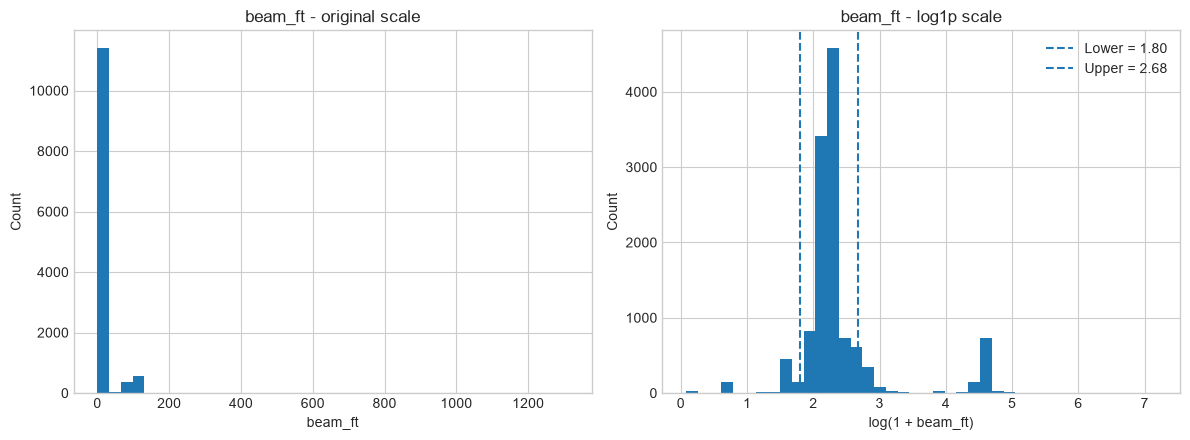

In [137]:
beam_result = inspect_iqr_outliers(
    df,
    feature="beam_ft",
    use_log=True,
    iqr_multiplier=3,
)

In [138]:
df[np.log1p(df["beam_ft"]) >= 3.5]

,type,boatClass,make,model,year,condition,length_ft,beam_ft,dryWeight_lb,hullMaterial,fuelType,numEngines,totalHP,minEngineYear,engineCategory,price,sellerId,city,state,created_days_since_ref
112,power,power-center,Epic,22 SC,2015,used,22.6000,102.0000,NaN,fiberglass,gasoline,1,150.0000,NaN,outboard,10.1962,262329,Pembroke Pines,FL,3539
323,power,power-skiwake,Tige,ZX 1,2019,new,21.0000,102.0000,NaN,fiberglass,other,1,0.0000,NaN,NaN,11.7918,65089,Antioch,IL,3393
422,power,power-sportfish,Recon,985DC,2017,used,19.0000,99.0000,NaN,fiberglass,other,1,0.0000,NaN,NaN,10.7976,5268,Pewaukee,WI,3588
432,power,power-skiwake,Tige,R 20,2019,new,20.0000,102.0000,NaN,fiberglass,other,1,0.0000,NaN,NaN,11.3043,5268,Pewaukee,WI,3393
591,power,power-skiwake,Tige,ZX 1,2019,new,21.0000,102.0000,NaN,fiberglass,other,1,0.0000,NaN,NaN,11.7910,5268,Pewaukee,WI,3393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16797,power,power-bass,Grumman,16,1994,used,16.0000,75.0000,NaN,aluminum,gasoline,0,NaN,NaN,NaN,8.2918,34634,Middletown,PA,3076
16803,power,power-barge,Floating Boutique Hotel Barge,NaN,2009,used,375.0000,85.0000,NaN,steel,other,0,NaN,NaN,NaN,15.5905,47422,Tampa,FL,2007
16878,power,power-bass,FishCraft,1600 XLVEE,1987,used,16.0000,92.0000,NaN,fiberglass,gasoline,0,NaN,NaN,NaN,8.5174,55696,La Follette,TN,3213
16946,power,power-aluminum,Tracker,1654 MVX SPORTSMAN,2018,used,16.0000,58.0000,NaN,aluminum,gasoline,0,NaN,NaN,NaN,9.2004,35112,Destin,FL,3450


2.2 Missing Values

In [66]:
ABSENCE_CATEGORICAL = []

missing_summary = (
    df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_count", "mean": "missing_rate"})
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)
missing_summary["interpretation"] = np.where(
    missing_summary.index.isin(ABSENCE_CATEGORICAL),
    "expected structural absence",
    "ordinary missing value",
)
missing_summary

,missing_count,missing_rate,interpretation
minEngineYear,"16,729.0000",0.8850,ordinary missing value
maxEngineYear,"16,698.0000",0.8834,ordinary missing value
dryWeight_lb,"11,809.0000",0.6247,ordinary missing value
engineCategory,"10,493.0000",0.5551,ordinary missing value
zip,"8,688.0000",0.4596,ordinary missing value
beam_ft,"6,504.0000",0.3441,ordinary missing value
fuelType,"2,952.0000",0.1562,ordinary missing value
totalHP,848.0000,0.0449,ordinary missing value
city,56.0000,0.0030,ordinary missing value
model,35.0000,0.0019,ordinary missing value


In [67]:
# if Boat does not have an engine, then surely min/maxEngine Year will be NaN

boats_with_engines = df[df['numEngines'] > 0] # any condition here
missing_summary = (
    boats_with_engines.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_count", "mean": "missing_rate"})
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)
missing_summary["interpretation"] = np.where(
    missing_summary.index.isin(ABSENCE_CATEGORICAL),
    "expected structural absence",
    "ordinary missing value",
)
missing_summary

# flag this. Any imputation and one-hot encoding will be saved AFTER train-test split

,missing_count,missing_rate,interpretation
minEngineYear,"15,881.0000",0.8796,ordinary missing value
maxEngineYear,"15,850.0000",0.8779,ordinary missing value
dryWeight_lb,"11,055.0000",0.6123,ordinary missing value
engineCategory,"9,645.0000",0.5342,ordinary missing value
zip,"8,585.0000",0.4755,ordinary missing value
beam_ft,"6,329.0000",0.3505,ordinary missing value
fuelType,"2,882.0000",0.1596,ordinary missing value
city,51.0000,0.0028,ordinary missing value
model,27.0000,0.0015,ordinary missing value


2.3 Target Distribution and Scale

In [68]:
target_summary = df["price"].describe().to_frame("price")
target_summary.loc["skew"] = df["price"].skew()
target_summary

,price
count,"18,903.0000"
mean,"647,146.8809"
std,"73,095,667.9668"
min,500.0000
25%,"19,255.0000"
50%,"34,195.0000"
75%,"57,830.0000"
max,"9,999,999,999.0000"
skew,135.5852


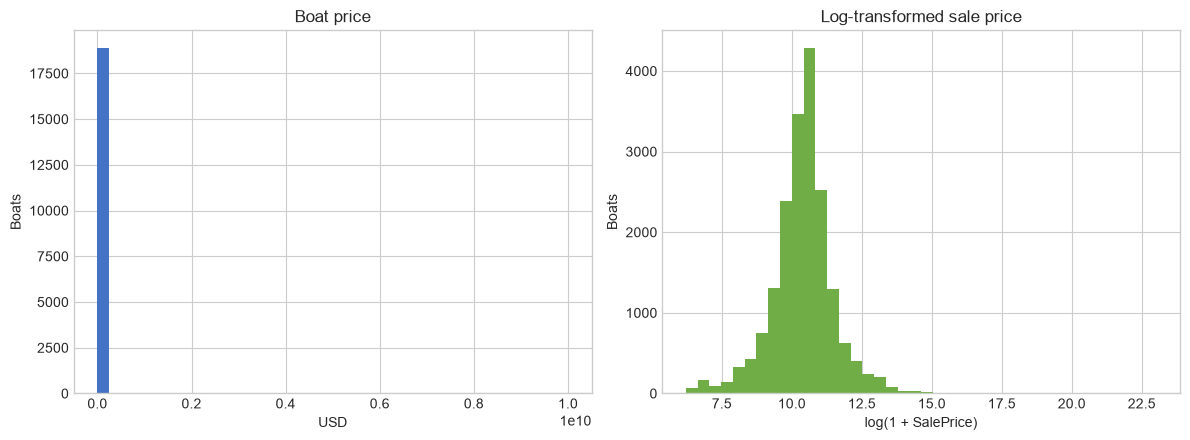

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df["price"].hist(bins=40, ax=axes[0], color="#4472C4")
axes[0].set(title="Boat price", xlabel="USD", ylabel="Boats")
np.log1p(df["price"]).hist(bins=40, ax=axes[1], color="#70AD47")
axes[1].set(title="Log-transformed sale price", xlabel="log(1 + SalePrice)", ylabel="Boats")
plt.tight_layout()
plt.show()

# probably log-transform for regression

In [70]:
df["price"] = np.log1p(df['price'])

2.4 Numerical and Categorical Relationships

In [84]:
# inspect correlation with the target

numeric_correlations = (
    df.select_dtypes(include=np.number)
    .corr()["price"]
    .drop("price")
    .sort_values(key=abs, ascending=False)
)
numeric_correlations.to_frame("correlation_with_sale_price")

,correlation_with_sale_price
dryWeight_lb,0.4746
totalHP,0.4499
numEngines,0.3841
length_ft,0.3508
minEngineYear,0.1699
beam_ft,0.1026
year,0.0921
created_days_since_ref,-0.0438
sellerId,-0.0162


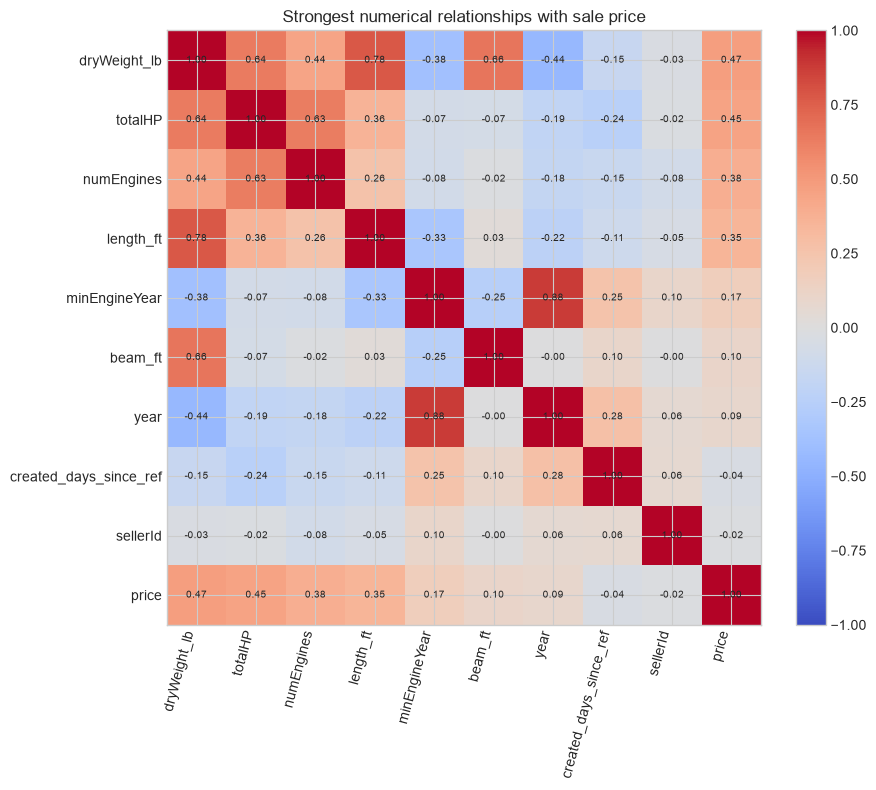

In [85]:
top_numeric = numeric_correlations.index.tolist() + ["price"]
corr_subset = df[top_numeric].corr()

plt.figure(figsize=(10, 8))
image = plt.imshow(corr_subset, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_subset)), corr_subset.columns, rotation=75, ha="right")
plt.yticks(range(len(corr_subset)), corr_subset.index)
for row in range(len(corr_subset)):
    for column in range(len(corr_subset)):
        plt.text(column, row, f"{corr_subset.iloc[row, column]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Strongest numerical relationships with sale price")
plt.tight_layout()
plt.show()

In [77]:
# When two columns are highly correlated (e.g. min/max Engine Year and Id/CreatedDaySinceRef: drop one
df = df.drop(columns = ['id'])

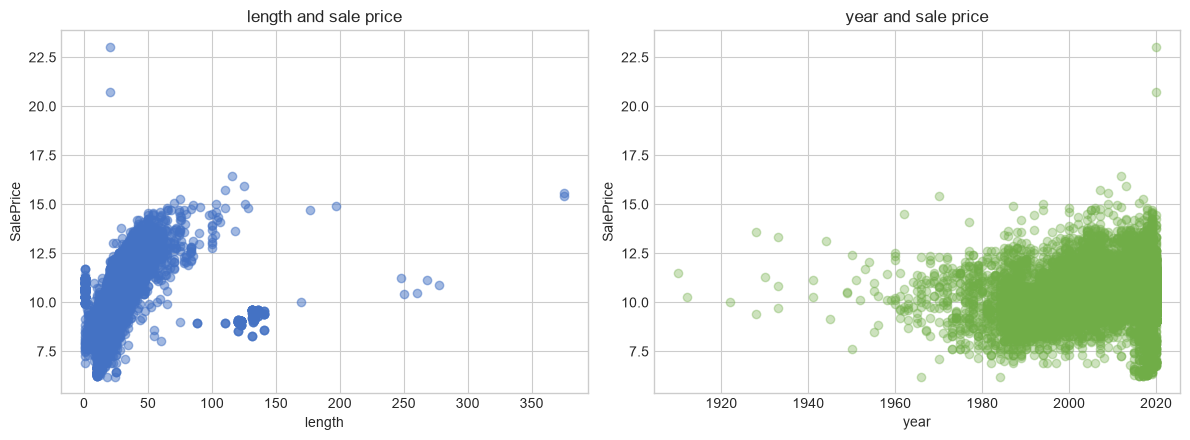

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(df["length_ft"], df["price"], alpha=0.5, color="#4472C4")
axes[0].set(title="length and sale price", xlabel="length", ylabel="SalePrice")
axes[1].scatter(df["year"], df["price"], alpha=0.35, color="#70AD47")
axes[1].set(title="year and sale price", xlabel="year", ylabel="SalePrice")
plt.tight_layout()
plt.show()

In [86]:
for column in ["type", "boatClass", "condition", "hullMaterial","zip"]:
    table = (
        df.groupby(column, dropna=False)["price"]
        .agg(count="size", median_price="median", mean_price="mean")
        .sort_values("median_price", ascending=False)
    )
    print(f"\n{column}")
    display(table)


type


,count,median_price,mean_price
type,,,
sail,254,10.5942,10.6683
power,18610,10.4400,10.3903
unpowered,39,7.8240,7.6659



boatClass


,count,median_price,mean_price
boatClass,,,
power-barge,3,15.4249,14.3625
power-mega,27,13.7090,13.7108
power-passenger,3,13.0170,13.3732
sail-catamaran,8,12.7540,12.6062
sail-centercockpit,6,12.7181,12.6561
...,...,...,...
sail-day,12,8.6784,9.3082
sail-schooner,3,8.5234,9.5108
unpowered-dinghy,4,7.8928,7.8206



condition


,count,median_price,mean_price
condition,,,
used,7714,10.4603,10.4679
new,11189,10.4384,10.3336



hullMaterial


,count,median_price,mean_price
hullMaterial,,,
steel,25,11.7745,11.4163
composite,159,10.8097,11.0162
fiberglass,8148,10.6919,10.7547
wood,63,10.5160,10.7337
other,5304,10.3478,10.1996
hypalon,19,10.3090,10.1816
aluminum,5152,10.2033,9.9852
ferro-cement,11,9.7051,10.0923
pvc,22,7.9398,8.2999



zip


,count,median_price,mean_price
zip,,,
33131,1,15.0091,15.0091
12180,1,14.8973,14.8973
33335,1,14.6264,14.6264
34216,2,14.6248,14.6248
11733,2,14.5897,14.5897
...,...,...,...
66712,13,7.0909,7.2922
57201,2,7.0123,7.0123
74953,1,7.0040,7.0040


In [88]:
# investigate relateion between categorical and numerical

zip_year_summary = (
    df.groupby("zip", dropna=False)["year"]
      .agg(
          count="size",
          mean_year="mean",
          median_year="median",
          min_year="min",
          max_year="max",
      )
      .sort_values("count", ascending=False)
)

display(zip_year_summary)

,count,mean_year,median_year,min_year,max_year
zip,,,,,
NaN,8688,"2,014.0033","2,019.0000",1928,2020
70072,268,"2,004.9552","2,006.0000",1964,2020
28560,183,"2,018.5792","2,019.0000",1993,2020
53072,171,"2,010.1345","2,015.0000",1962,2020
54904,119,"2,009.5378","2,014.0000",1933,2020
...,...,...,...,...,...
02568,1,"2,005.0000","2,005.0000",2005,2005
02571,1,"2,018.0000","2,018.0000",2018,2018
02620,1,"2,000.0000","2,000.0000",2000,2000


In [97]:
# decide to drop zip for now:

df = df.drop(columns = ['zip'])

3. Train-Test Split

In [98]:
TARGET = "price"
# ID_COLUMN = "Id"

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

price_bands = pd.qcut(y, q=10, duplicates="drop") # remove this line if do not want to stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_bands,  # remove this if do not want to stratify
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "mean_price": [y_train.mean(), y_test.mean()],
    "median_price": [y_train.median(), y_test.median()],
    "minimum_price": [y_train.min(), y_test.min()],
    "maximum_price": [y_train.max(), y_test.max()],
}, index=["train", "test"])
split_summary

,rows,mean_price,median_price,minimum_price,maximum_price
train,15122,10.3893,10.4399,6.2166,23.0259
test,3781,10.3848,10.4391,6.2538,16.4546


4. Baseline Preprocessing

In [101]:
# 4.1: Baseline Preprocessing

ORDINAL_CATEGORIES = {}
ORDINAL_STRUCTURAL_ABSENCE = {}


def select_numeric(frame):
    return [
        column for column in frame.select_dtypes(include=np.number).columns
        if column not in ORDINAL_CATEGORIES
    ]


def select_nominal(frame):
    return [
        column for column in frame.select_dtypes(exclude=np.number).columns
        if column not in ORDINAL_CATEGORIES
    ]


def make_ordinal_pipeline(column):
    steps = []
    if column in ORDINAL_STRUCTURAL_ABSENCE:
        steps.append((
            "structural_absence",
            SimpleImputer(
                strategy="constant",
                fill_value=ORDINAL_STRUCTURAL_ABSENCE[column],
            ),
        ))

    steps.extend([
        (
            "ordinal",
            OrdinalEncoder(
                categories=[ORDINAL_CATEGORIES[column]],
                handle_unknown="use_encoded_value",
                unknown_value=np.nan,
                encoded_missing_value=np.nan,
            ),
        ),
        ("imputer", SimpleImputer(strategy="median")),
    ])
    return Pipeline(steps)


def make_preprocessor(*, dense=False, scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    transformers = [
        ("numeric", Pipeline(numeric_steps), select_numeric),
        (
            "nominal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=not dense)),
            ]),
            select_nominal,
        ),
    ]

    transformers.extend(
        (f"ordinal_{column}", make_ordinal_pipeline(column), [column])
        for column in ORDINAL_CATEGORIES
    )
    return ColumnTransformer(transformers)


baseline_preprocessor = make_preprocessor()

dummy_model = Pipeline([
    ("preprocess", clone(baseline_preprocessor)),
    ("model", DummyRegressor(strategy="median")),
])

baseline_linear = Pipeline([
    ("preprocess", clone(baseline_preprocessor)),
    ("model", LinearRegression()),
])

In [102]:
# 4.2 Cross Validation

def rmsle_clipped(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    y_true = np.asarray(y_true)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
    "rmsle": make_scorer(rmsle_clipped, greater_is_better=False),
}


def evaluate_model_cv(name, estimator, X_data=X_train, y_data=y_train):
    scores = cross_validate(
        estimator,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    return {
        "model": name,
        "rmse_mean": -scores["test_rmse"].mean(),
        "rmse_std": scores["test_rmse"].std(),
        "mae_mean": -scores["test_mae"].mean(),
        "mae_std": scores["test_mae"].std(),
        "r2_mean": scores["test_r2"].mean(),
        "r2_std": scores["test_r2"].std(),
        "rmsle_mean": -scores["test_rmsle"].mean(),
        "rmsle_std": scores["test_rmsle"].std(),
        "fit_time_seconds": scores["fit_time"].mean(),
    }


baseline_results = [
    evaluate_model_cv("Median dummy", dummy_model),
    evaluate_model_cv("Baseline linear", baseline_linear),
]
pd.DataFrame(baseline_results).set_index("model").T


model,Median dummy,Baseline linear
rmse_mean,1.1120,0.7398
rmse_std,0.0254,0.0381
mae_mean,0.7835,0.3731
mae_std,0.0191,0.0151
r2_mean,-0.0024,0.5541
r2_std,0.0015,0.0538
rmsle_mean,0.1008,0.0692
rmsle_std,0.0028,0.0041
fit_time_seconds,0.1135,3.1344


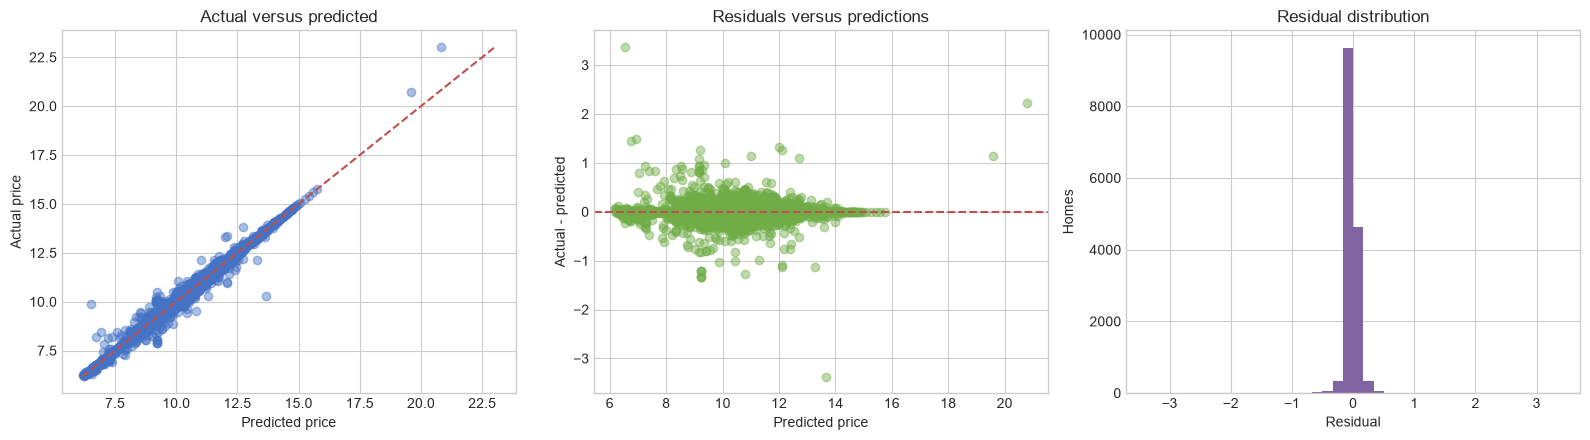

In [103]:
baseline_linear.fit(X_train, y_train)
baseline_train_prediction = baseline_linear.predict(X_train)
baseline_train_residual = y_train - baseline_train_prediction

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(baseline_train_prediction, y_train, alpha=0.45, color="#4472C4")
line_limits = [min(y_train.min(), baseline_train_prediction.min()), max(y_train.max(), baseline_train_prediction.max())]
axes[0].plot(line_limits, line_limits, color="#C0504D", linestyle="--")
axes[0].set(title="Actual versus predicted", xlabel="Predicted price", ylabel="Actual price")
axes[1].scatter(baseline_train_prediction, baseline_train_residual, alpha=0.45, color="#70AD47")
axes[1].axhline(0, color="#C0504D", linestyle="--")
axes[1].set(title="Residuals versus predictions", xlabel="Predicted price", ylabel="Actual - predicted")
axes[2].hist(baseline_train_residual, bins=40, color="#8064A2")
axes[2].set(title="Residual distribution", xlabel="Residual", ylabel="Homes")
plt.tight_layout()
plt.show()

5. Feature Engineering

In [104]:
def with_log_target(regressor):
    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=True,
    )


log_target_linear = with_log_target(Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", LinearRegression()),
]))

log_target_result = evaluate_model_cv("Linear with log target", log_target_linear)
pd.DataFrame([*baseline_results, log_target_result]).set_index("model")

,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,rmsle_mean,rmsle_std,fit_time_seconds
model,,,,,,,,,
Median dummy,1.1120,0.0254,0.7835,0.0191,-0.0024,0.0015,0.1008,0.0028,0.1135
Baseline linear,0.7398,0.0381,0.3731,0.0151,0.5541,0.0538,0.0692,0.0041,3.1344
Linear with log target,0.7409,0.0388,0.3774,0.0139,0.5529,0.0536,0.0653,0.0028,2.3555


In [105]:
class AmesFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X


class SkewedLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=0.75):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        X = X.copy()
        numeric = X.select_dtypes(include=np.number)
        nonnegative = [column for column in numeric if numeric[column].min(skipna=True) >= 0]
        skew = numeric[nonnegative].skew().abs()
        self.columns_ = skew[skew > self.skew_threshold].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for column in self.columns_:
            X[column] = np.log1p(X[column])
        return X


engineered_linear = with_log_target(Pipeline([
    ("features", AmesFeatureEngineer()),
    ("skew", SkewedLogTransformer()),
    ("preprocess", make_preprocessor()),
    ("model", LinearRegression()),
]))

engineered_result = evaluate_model_cv("Engineered linear", engineered_linear)
pd.DataFrame([*baseline_results, log_target_result, engineered_result]).set_index("model")

,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,rmsle_mean,rmsle_std,fit_time_seconds
model,,,,,,,,,
Median dummy,1.1120,0.0254,0.7835,0.0191,-0.0024,0.0015,0.1008,0.0028,0.1135
Baseline linear,0.7398,0.0381,0.3731,0.0151,0.5541,0.0538,0.0692,0.0041,3.1344
Linear with log target,0.7409,0.0388,0.3774,0.0139,0.5529,0.0536,0.0653,0.0028,2.3555
Engineered linear,0.7431,0.0363,0.3786,0.0123,0.5504,0.0501,0.0655,0.0026,2.2110


6.1:  Ridge and Lasso Regression

In [106]:
def make_regularized_model(estimator):
    return with_log_target(Pipeline([
        ("features", AmesFeatureEngineer()),
        ("skew", SkewedLogTransformer()),
        ("preprocess", make_preprocessor()),
        ("model", estimator),
    ]))


ridge_model = make_regularized_model(Ridge(max_iter=20_000))
ridge_search = GridSearchCV(
    ridge_model,
    param_grid={"regressor__model__alpha": [0.1, 1.0, 10.0, 30.0, 100.0]},
    scoring=make_scorer(rmsle_clipped, greater_is_better=False),
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)
ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_["regressor__model__alpha"])
print("Best Ridge CV RMSLE:", round(-ridge_search.best_score_, 4))
pd.DataFrame(ridge_search.cv_results_)[
    ["param_regressor__model__alpha", "mean_train_score", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)

Best Ridge alpha: 1.0
Best Ridge CV RMSLE: 0.0397


,param_regressor__model__alpha,mean_train_score,mean_test_score,std_test_score
1,1.0000,-0.0210,-0.0397,0.0007
0,0.1000,-0.0110,-0.0428,0.0006
2,10.0000,-0.0379,-0.0439,0.0006
3,30.0000,-0.0447,-0.0478,0.0007
4,100.0000,-0.0511,-0.0526,0.0009


In [113]:
lasso_model = make_regularized_model(Lasso(max_iter=50_000, selection="cyclic"))
lasso_search = GridSearchCV(
    lasso_model,
    param_grid={"regressor__model__alpha":  [0.0001, 0.0003, 0.001, 0.003, 0.01]},
    scoring=make_scorer(rmsle_clipped, greater_is_better=False),
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)
lasso_search.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_search.best_params_["regressor__model__alpha"])
print("Best Lasso CV RMSLE:", round(-lasso_search.best_score_, 4))
pd.DataFrame(lasso_search.cv_results_)[
    ["param_regressor__model__alpha", "mean_train_score", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)

Best Lasso alpha: 0.0001
Best Lasso CV RMSLE: 0.051


,param_regressor__model__alpha,mean_train_score,mean_test_score,std_test_score
0,0.0001,-0.0499,-0.0510,0.0010
1,0.0003,-0.0563,-0.0568,0.0011
2,0.0010,-0.0617,-0.0619,0.0011
3,0.0030,-0.0681,-0.0682,0.0013
4,0.0100,-0.0733,-0.0734,0.0016


In [108]:
best_lasso = lasso_search.best_estimator_
fitted_lasso_pipeline = best_lasso.regressor_
lasso_feature_names = fitted_lasso_pipeline.named_steps["preprocess"].get_feature_names_out()
lasso_coefficients = pd.Series(
    fitted_lasso_pipeline.named_steps["model"].coef_,
    index=lasso_feature_names,
    name="coefficient_on_log_price",
)
selected_lasso_features = (
    lasso_coefficients[lasso_coefficients.ne(0)]
    .sort_values(key=abs, ascending=False)
    .to_frame()
)

print(f"Selected {len(selected_lasso_features)} of {len(lasso_coefficients)} transformed features")
selected_lasso_features.head(30)

Selected 130 of 8820 transformed features


,coefficient_on_log_price
nominal__type_unpowered,-0.1443
nominal__model_Topper 1236 Riveted Jon,-0.1314
nominal__model_Topper 1036 Riveted Jon,-0.1258
nominal__make_Jackson,-0.1031
nominal__boatClass_power-util,-0.0988
nominal__boatClass_power-jon,-0.0925
nominal__fuelType_diesel,0.0880
nominal__boatClass_power-pwc,-0.0855
nominal__boatClass_power-antique,0.0805
nominal__model_Topper 1436 Riveted Jon,-0.0693


6.2: Random Forest

In [114]:
rf_selector = RandomForestRegressor(
    n_estimators=75,   # no time to tune, but if allows: focus on learning_rate and n_estimators
    min_samples_leaf=2,
    max_features=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_estimator = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=2,
    max_features=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_selected = with_log_target(Pipeline([
    ("features", AmesFeatureEngineer()),
    ("preprocess", make_preprocessor(scale_numeric=False)),
    ("select", SelectFromModel(rf_selector, threshold="median")),
    ("model", rf_estimator),
]))

rf_result = evaluate_model_cv("RF with impurity selection", rf_selected)
rf_result

{'model': 'RF with impurity selection',
 'rmse_mean': np.float64(0.33288897313034393),
 'rmse_std': np.float64(0.025944951176078555),
 'mae_mean': np.float64(0.17990513723523086),
 'mae_std': np.float64(0.005274213593282915),
 'r2_mean': np.float64(0.9095653836418324),
 'r2_std': np.float64(0.014889119778149612),
 'rmsle_mean': np.float64(0.0297086215816465),
 'rmsle_std': np.float64(0.0010963920058277654),
 'fit_time_seconds': np.float64(38.50259313583374)}

In [115]:
rf_selected.fit(X_train, y_train)
fitted_rf_pipeline = rf_selected.regressor_
rf_all_feature_names = fitted_rf_pipeline.named_steps["preprocess"].get_feature_names_out()
rf_support = fitted_rf_pipeline.named_steps["select"].get_support()
rf_selected_feature_names = rf_all_feature_names[rf_support]
rf_importance = pd.Series(
    fitted_rf_pipeline.named_steps["model"].feature_importances_,
    index=rf_selected_feature_names,
    name="impurity_importance",
).sort_values(ascending=False)

print(f"Selected {rf_support.sum()} of {len(rf_support)} transformed features")
rf_importance.head(30).to_frame()

Selected 8820 of 8820 transformed features


,impurity_importance
numeric__length_ft,0.4011
numeric__year,0.1339
numeric__dryWeight_lb,0.1071
numeric__beam_ft,0.0914
numeric__totalHP,0.0566
nominal__boatClass_power-pwc,0.0242
numeric__numEngines,0.0214
nominal__boatClass_power-jon,0.0147
nominal__boatClass_power-pontoon,0.0134
numeric__created_days_since_ref,0.0112


6.4 Gradient Boosting

In [116]:
boosting_model = with_log_target(Pipeline([
    ("features", AmesFeatureEngineer()),
    ("preprocess", make_preprocessor(dense=True, scale_numeric=False)),
    (
        "model",
        GradientBoostingRegressor(  # no time to tune, but if allows: focus on learning_rate and n_estimators
            learning_rate=0.05,
            n_estimators=300,
            max_depth=2,
            min_samples_leaf=10,
            loss="huber",
            random_state=RANDOM_STATE,
        ),
    ),
]))

boosting_result = evaluate_model_cv("Gradient boosting", boosting_model)
boosting_result

KeyboardInterrupt: 

7. Compare all results

In [117]:
ridge_result = evaluate_model_cv("Ridge", ridge_search.best_estimator_)
lasso_result = evaluate_model_cv("Lasso", lasso_search.best_estimator_)

all_results = pd.DataFrame([
    *baseline_results,
    log_target_result,
    engineered_result,
    ridge_result,
    lasso_result,
    rf_result
    #boosting_result,
])

model_comparison = (
    all_results[
        [
            "model",
            "rmsle_mean",
            "rmsle_std",
            "rmse_mean",
            "rmse_std",
            "mae_mean",
            "r2_mean",
            "fit_time_seconds",
        ]
    ]
    .sort_values("rmsle_mean")
    .reset_index(drop=True)
)
model_comparison

,model,rmsle_mean,rmsle_std,rmse_mean,rmse_std,mae_mean,r2_mean,fit_time_seconds
0,RF with impurity selection,0.0297,0.0011,0.3329,0.0259,0.1799,0.9096,38.5026
1,Ridge,0.0397,0.0007,0.4468,0.0194,0.2761,0.8377,0.1457
2,Lasso,0.0510,0.0010,0.5701,0.0207,0.3943,0.7361,0.2844
3,Linear with log target,0.0653,0.0028,0.7409,0.0388,0.3774,0.5529,2.3555
4,Engineered linear,0.0655,0.0026,0.7431,0.0363,0.3786,0.5504,2.2110
5,Baseline linear,0.0692,0.0041,0.7398,0.0381,0.3731,0.5541,3.1344
6,Median dummy,0.1008,0.0028,1.1120,0.0254,0.7835,-0.0024,0.1135


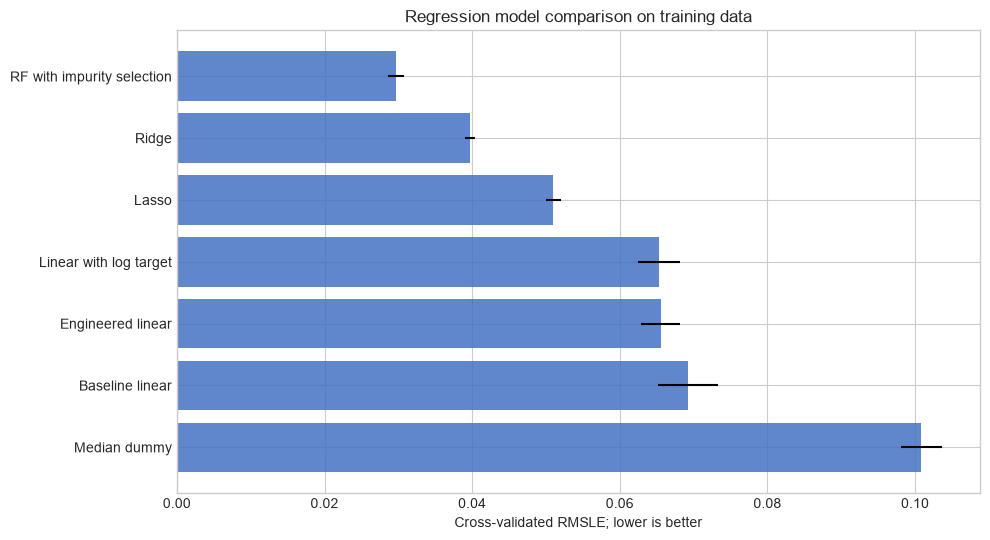

In [118]:
plot_data = model_comparison.sort_values("rmsle_mean", ascending=False)
plt.figure(figsize=(10, 5.5))
plt.barh(
    plot_data["model"],
    plot_data["rmsle_mean"],
    xerr=plot_data["rmsle_std"],
    color="#4472C4",
    alpha=0.85,
)
plt.xlabel("Cross-validated RMSLE; lower is better")
plt.ylabel("")
plt.title("Regression model comparison on training data")
plt.tight_layout()
plt.show()

8. Test the models on Untouched test set

In [120]:
candidate_models = {
    "Median dummy": dummy_model,
    "Baseline linear": baseline_linear,
    "Linear with log target": log_target_linear,
    "Engineered linear": engineered_linear,
    "Ridge": ridge_search.best_estimator_,
    "Lasso": lasso_search.best_estimator_,
    "RF with impurity selection": rf_selected
   # "Gradient boosting": boosting_model,
}

selected_model_name = model_comparison.loc[0, "model"]
final_model = clone(candidate_models[selected_model_name])
final_model.fit(X_train, y_train)

test_prediction = np.clip(final_model.predict(X_test), 0, None)
test_metrics = pd.Series({
    "rmse_usd": root_mean_squared_error(y_test, test_prediction),
    "mae_usd": mean_absolute_error(y_test, test_prediction),
    "r2": r2_score(y_test, test_prediction),
    "rmsle": rmsle_clipped(y_test, test_prediction),
}, name="holdout_score")

print("Selected model:", selected_model_name)
test_metrics.to_frame()

Selected model: RF with impurity selection


,holdout_score
rmse_usd,0.3081
mae_usd,0.1724
r2,0.9228
rmsle,0.0287


In [124]:
# rank the selected models on test set -- only used to confirm validness of model-choosing process, do not use to choose models!

holdout_results = []

for name in ["Ridge", "Lasso", "RF with impurity selection"]:
    model = clone(candidate_models[name])
    model.fit(X_train, y_train)

    pred = np.clip(model.predict(X_test), 0, None)

    holdout_results.append({
        "model": name,
        "holdout_rmsle": rmsle_clipped(y_test, pred),
    })

pd.DataFrame(holdout_results).sort_values("holdout_rmsle")

,model,holdout_rmsle
2,RF with impurity selection,0.0287
0,Ridge,0.0399
1,Lasso,0.0521


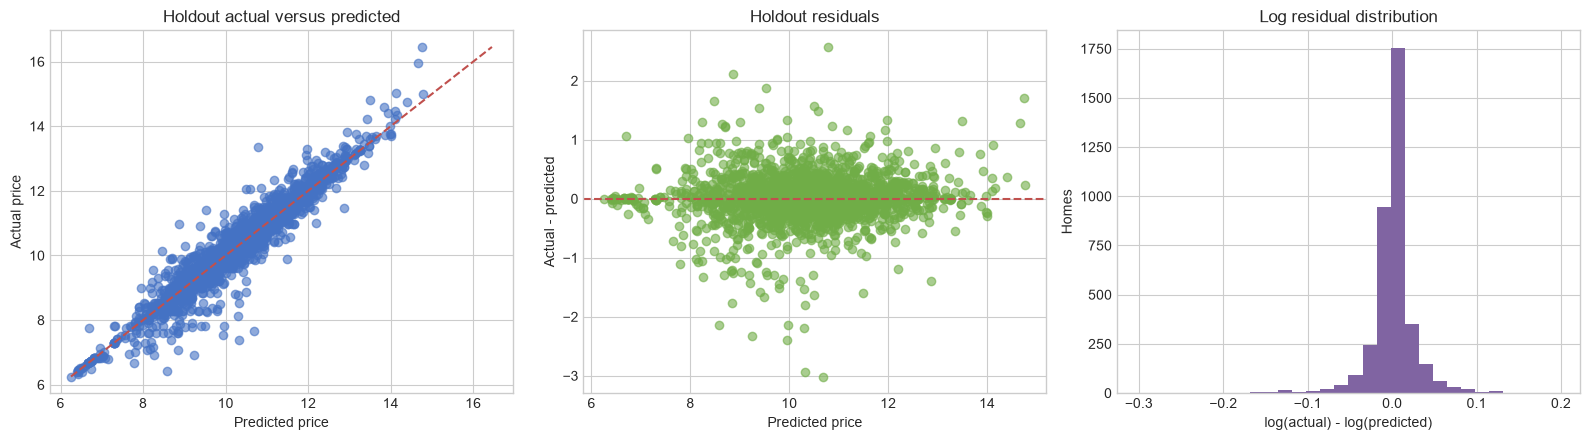

In [121]:
test_residual = y_test - test_prediction
log_residual = np.log1p(y_test) - np.log1p(test_prediction)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(test_prediction, y_test, alpha=0.6, color="#4472C4")
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[0].plot(limits, limits, color="#C0504D", linestyle="--")
axes[0].set(title="Holdout actual versus predicted", xlabel="Predicted price", ylabel="Actual price")
axes[1].scatter(test_prediction, test_residual, alpha=0.6, color="#70AD47")
axes[1].axhline(0, color="#C0504D", linestyle="--")
axes[1].set(title="Holdout residuals", xlabel="Predicted price", ylabel="Actual - predicted")
axes[2].hist(log_residual, bins=30, color="#8064A2")
axes[2].set(title="Log residual distribution", xlabel="log(actual) - log(predicted)", ylabel="Homes")
plt.tight_layout()
plt.show()

In [122]:
holdout_diagnostics = pd.DataFrame({
    "actual": y_test,
    "predicted": test_prediction,
    "absolute_error": np.abs(test_residual),
    "absolute_percentage_error": np.abs(test_residual) / y_test,
})
holdout_diagnostics["actual_price_quartile"] = pd.qcut(
    holdout_diagnostics["actual"],
    q=4,
    duplicates="drop",
)

error_by_price_band = holdout_diagnostics.groupby(
    "actual_price_quartile",
    observed=True,
).agg(
    homes=("actual", "size"),
    mean_actual_price=("actual", "mean"),
    mae=("absolute_error", "mean"),
    median_absolute_percentage_error=("absolute_percentage_error", "median"),
)
error_by_price_band

,homes,mean_actual_price,mae,median_absolute_percentage_error
actual_price_quartile,,,,
"(6.252999999999999, 9.878]",946,9.0186,0.2385,0.0122
"(9.878, 10.439]",945,10.1797,0.1304,0.0062
"(10.439, 10.965]",945,10.6739,0.1204,0.0057
"(10.965, 16.455]",945,11.6685,0.2003,0.0102


In [123]:
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring=make_scorer(rmsle_clipped, greater_is_better=False),
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_summary = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
permutation_summary.head(30)

,feature,importance_mean,importance_std
0,length_ft,0.0738,0.0006
1,year,0.0467,0.0004
2,boatClass,0.0129,0.0002
3,dryWeight_lb,0.0104,0.0004
4,beam_ft,0.0062,0.0003
5,totalHP,0.0048,0.0003
6,make,0.0030,0.0000
7,fuelType,0.0019,0.0001
8,hullMaterial,0.0015,0.0001
9,model,0.0010,0.0000
